In [1]:
import scipy
import matplotlib.pyplot as plt
import numpy as np
import csv
import time
import pandas as pd
import varray as va
import ldax_processing as ldax
from datetime import datetime
from scipy.optimize import curve_fit, minimize

In [12]:
# mV to ADCC unit conversions
# Use either extrema_mv[:,:,:,1] (undershoot) or extrema_mv[:,:,:,2] (signal)

def convert_to_adcc(mvValues):
    adccValues = mvValues/0.122
    return adccValues

# Calculate approximate errors for signal readouts based on scale
# Based on: 5 subdivisions per division, error is half the smallest division on measurement device; 1/5*1/2 = 1/10

def calc_err(extrema):
    und_err = extrema[0,:,:,3]/10
    sig_err = extrema[0,:,:,4]/10
    return und_err, sig_err

# Calculate error propagation to signal/undershoot and undershoot/signal ratios

def calc_div_err(ratio, extrema, und_err, sig_err):
    with np.errstate(divide='ignore', invalid='ignore'):
        div_err = np.nan_to_num(ratio*np.sqrt(((und_err/extrema[0,:,:,1])**2)+((sig_err/extrema[0,:,:,2])**2)))
    return div_err
    
# Calculate signal/undershoot ratio, use arrays using same units for extrema

def calc_suratio(extrema):
    with np.errstate(divide='ignore', invalid='ignore'):
        suratio = np.divide(extrema[0,:,:,2],extrema[0,:,:,1],out=np.zeros_like(extrema[0,:,:,1],dtype=float),where=extrema[0,:,:,1]!=0)
    return suratio

# Calculate undershoot/signal ratio, use arrays using same units for extrema

def calc_usratio(extrema):
    with np.errstate(divide='ignore', invalid='ignore'):
        usratio = np.divide(extrema[0,:,:,1],extrema[0,:,:,2],out=np.zeros_like(extrema[0,:,:,1],dtype=float),where=extrema[0,:,:,2]!=0)
    return usratio

In [47]:
# Data set format:

# 2-Layer Board: b2
# 4-Layer Board: b4
# Design 1: 10K R1, 10k R6-9 resistors -- d1
# Design 2: 100 R1, 10k R6-9 resistors -- d2
# Design 3: 100 R1, 100 R6-9 resistors -- d3
# Design 4: 10K R1, 100 R6-9 resistors -- d4

# 2-layer board, design 1: b2d1
# Error ~ +/- 0.05 mV for 0.5 mV scale readouts
# Error ~ +/- 0.2 mV for 2 mV scale readouts
# Error ~ +/- 0.5 mV for 5 mV scale readouts
# Error ~ +/- 1 mV for 10 mV scale readouts
# Error ~ +/- 2 mV for 20 mV scale readouts

# ALL DATA SETS ARE FROM SIG1/SIG4 CHANNELS ONLY

# extrema_mv records the maximum undershoot and signal voltages for all designs
# extrema_mv[Board, Design, Data entry, Data type]
# Data types: [0] = LED voltage | [1] = max undershoot | [2] = max signal | [3] = Scale of undershoot readout at recording (mV) | [4] = Scale of signal readout at recording

extrema_mv = np.zeros((2,4,11,5))
extrema_mv[0,0,:,:] = [[2.60,0,0,2,2],[2.65,0,0,2,2],[2.70,0,0,2,2],[2.75,0.5,4,2,2],[2.80,1.5,8,2,2],[2.85,2,10,2,2],[2.90,2.5,20,2,5],[2.95,3.2,27,2,5],[3.00,3.6,36,2,10],[3.05,4.6,50,2,10],[3.10,4.8,68,2,20]]
extrema_mv[0,1,:,:] = [[2.60,0,21,0.5,5],[2.65,0,87,0.5,20],[2.70,0.1,225,0.5,50],[2.75,0.2,400,0.5,100],[2.80,0.4,560,0.5,100],[2.85,0.5,680,0.5,200],[2.90,0.6,760,0.5,200],[2.95,0.8,840,0.5,200],[3.00,0.9,880,0.5,200],[3.05,0.9,960,0.5,200],[3.10,0.9,960,0.5,200]]
extrema_mv[0,2,:,:] = [[2.60,0.4,2,2,2],[2.65,1,5,2,2],[2.70,4.4,15,2,5],[2.75,7.6,32,5,10],[2.80,15,45,5,10],[2.85,20,56,5,20],[2.90,21,68,10,20],[2.95,23,70,10,20],[3.00,25,75,10,50],[3.05,26,80,10,50],[3.10,26,80,10,50]]
extrema_mv[0,3,:,:] = [[2.60,0.4,11.6,2,2],[2.65,2,44,2,10],[2.70,3.6,120,2,50],[2.75,7.8,225,2,50],[2.80,13,320,5,100],[2.85,17.5,400,5,100],[2.90,20,450,10,100],[2.95,23,500,10,100],[3.00,24,550,10,100],[3.05,28,600,10,100],[3.10,30,650,10,200]]

extrema_adcc = np.zeros((2,4,11,5))
extrema_adcc[:,:,:,:] = extrema_mv
extrema_adcc[:,:,:,1] = convert_to_adcc(extrema_mv[:,:,:,1])
extrema_adcc[:,:,:,2] = convert_to_adcc(extrema_mv[:,:,:,2])
extrema_adcc[:,:,:,3] = convert_to_adcc(extrema_mv[:,:,:,3])
extrema_adcc[:,:,:,4] = convert_to_adcc(extrema_mv[:,:,:,4])

und_err, sig_err = calc_err(extrema_adcc)

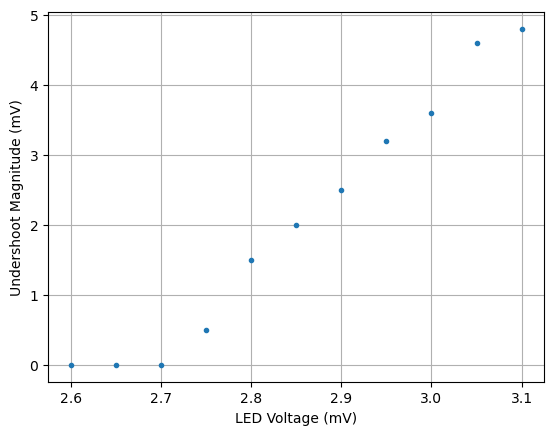

In [4]:
plt.plot(extrema_mv[0,0,:,0], extrema_mv[0,0,:,1], '.')
plt.xlabel('LED Voltage (mV)')
plt.ylabel('Undershoot Magnitude (mV)')
plt.grid()
plt.show()

In [63]:
print(extrema_adcc[0,3,:,1])
print(extrema_adcc[0,3,:,3]/10)

[  3.27868852  16.39344262  29.50819672  63.93442623 106.55737705
 143.44262295 163.93442623 188.52459016 196.72131148 229.50819672
 245.90163934]
[1.63934426 1.63934426 1.63934426 1.63934426 4.09836066 4.09836066
 8.19672131 8.19672131 8.19672131 8.19672131 8.19672131]


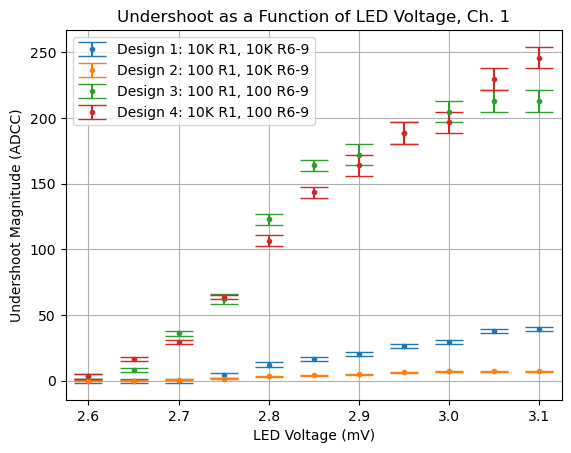

In [49]:
for i, value in enumerate(extrema_adcc[0,0:4,0,0]):
    plt.errorbar(extrema_adcc[0,i,:,0], extrema_adcc[0,i,:,1], yerr=und_err[i], fmt='.', capsize=10)
plt.xlabel('LED Voltage (mV)')
plt.ylabel('Undershoot Magnitude (ADCC)')
plt.title('Undershoot as a Function of LED Voltage, Ch. 1')
plt.legend(['Design 1: 10K R1, 10K R6-9','Design 2: 100 R1, 10K R6-9', 'Design 3: 100 R1, 100 R6-9', 'Design 4: 10K R1, 100 R6-9'])
plt.grid()
plt.show()

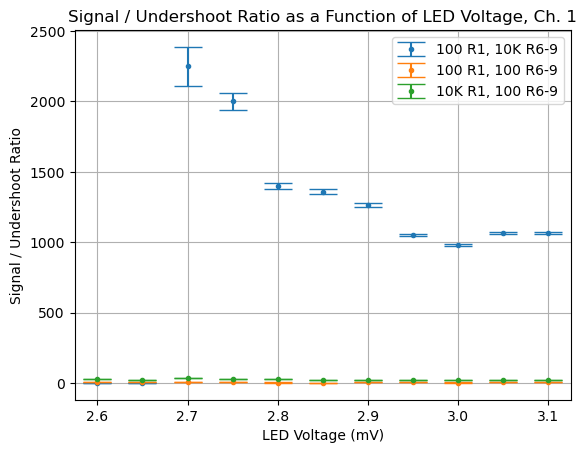

In [32]:
usratio = calc_usratio(extrema_adcc)
suratio = calc_suratio(extrema_adcc)
div_err = calc_div_err(suratio, extrema_adcc, und_err, sig_err)
for i, value in enumerate(extrema_adcc[0,0:3,0,0]):
    plt.errorbar(extrema_adcc[0,i+1,:,0], suratio[i+1], yerr=div_err[i+1], fmt='.', capsize=10)
#plt.ylim(0,20)
plt.xlabel('LED Voltage (mV)')
plt.ylabel('Signal / Undershoot Ratio')
plt.title('Signal / Undershoot Ratio as a Function of LED Voltage, Ch. 1')
plt.legend(['100 R1, 10K R6-9','100 R1, 100 R6-9', '10K R1, 100 R6-9'])
plt.grid()
plt.show()